<a href="https://colab.research.google.com/github/jobellet/Dynamics-of-Visual-Representations-in-a-Macaque-Ventrolateral-Prefrontal-Cortex/blob/main/DNN_metrics_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ──────────────────────────────────────────────────────────────────────
# DATA SETUP WIDGET (Universal: Colab, Kaggle & Local)
# ──────────────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import shutil
from pathlib import Path

# --- 1. CONFIGURATION
REQUIRED_FILES = [
    "category_decoding_accuracy.csv",
    "position_decoding_mae.csv",
    "network_mean_rsas_all_conditions.csv"
]

DEST_DIR = Path("downloads")
DEST_DIR.mkdir(exist_ok=True)

# Detect Environment
IN_COLAB = False
try:
    if 'google.colab' in str(get_ipython()):
        IN_COLAB = True
except NameError:
    pass
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

# --- UI Elements ---
style = {'description_width': '120px'}
layout_full = widgets.Layout(width='98%')

header = widgets.HTML("<h2>📂 Data Import Manager</h2>")

options = ['Local Upload']
if IN_COLAB:
    options = ['Google Drive', 'Local Upload']
elif IN_KAGGLE:
    options = ['Kaggle Input', 'Local Upload']
else:
    options = ['Local Storage', 'Local Upload']

source_toggle = widgets.ToggleButtons(
    options=options,
    description='Select Source:',
    button_style='info',
    style=style
)

path_input = widgets.Text(
    value='/content/drive/MyDrive/vlPFC_Geometry' if IN_COLAB else '.',
    placeholder='Enter absolute path to data folder...',
    description='Data Path:',
    disabled=False,
    layout=layout_full,
    style=style
)

btn_action = widgets.Button(
    description='Start Import',
    button_style='primary',
    icon='download',
    layout=widgets.Layout(width='200px')
)

out_log = widgets.Output(layout={'border': '1px solid #ddd', 'padding': '10px'})

# --- Logic ---
def update_ui(change):
    if source_toggle.value == 'Local Upload':
        path_input.layout.display = 'none'
    else:
        path_input.layout.display = 'flex'
        if source_toggle.value == 'Google Drive':
            path_input.description = 'Drive Path:'
        elif source_toggle.value == 'Local Storage':
            path_input.description = 'Local Path:'
        elif source_toggle.value == 'Kaggle Input':
            path_input.description = 'Input Path:'
            path_input.value = '/kaggle/input/vlpfc-geometry'

source_toggle.observe(update_ui, 'value')

def on_click_action(b):
    with out_log:
        clear_output()
        mode = source_toggle.value

        if mode == 'Local Upload':
            if IN_COLAB:
                from google.colab import files
                print("🚀 Upload files now (select all required files):")
                uploaded = files.upload()
                for name in uploaded:
                    shutil.move(name, DEST_DIR / name)
                print("\n✅ Upload complete.")
            else:
                print("⚠️ Manual upload widget is Colab-only.")
                print(f"👉 Please manually copy files to: {DEST_DIR.absolute()}")
            return

        src_path = Path(path_input.value)
        if mode == 'Google Drive' and not src_path.exists():
            from google.colab import drive
            print("🔄 Mounting Google Drive...")
            drive.mount('/content/drive')

        if not src_path.exists():
            print(f"❌ Error: Path not found: {src_path}")
            return

        print(f"🔎 Scanning {src_path} for files...")
        for fname in REQUIRED_FILES:
            dest = DEST_DIR / fname
            if dest.exists():
                print(f"   • {fname}: Already exists (Skipping)")
                continue

            found = list(src_path.rglob(fname))
            if found:
                print(f"   • Copying {fname}...", end=" ")
                shutil.copy(found[0], dest)
                print("Done.")
            else:
                print(f"   ❌ {fname}: Not found in source path.")

        missing = [f for f in REQUIRED_FILES if not (DEST_DIR / f).exists()]
        if not missing:
            print("\n🎉 Success! All files are in 'downloads/'. Run the next cell.")
        else:
            print(f"\n⚠️ Missing files: {missing}")

update_ui(None)
btn_action.on_click(on_click_action)
display(header, source_toggle, path_input, btn_action, out_log)

✅ Saved merged metrics data to 'Statistics/merged_metrics_table.csv'


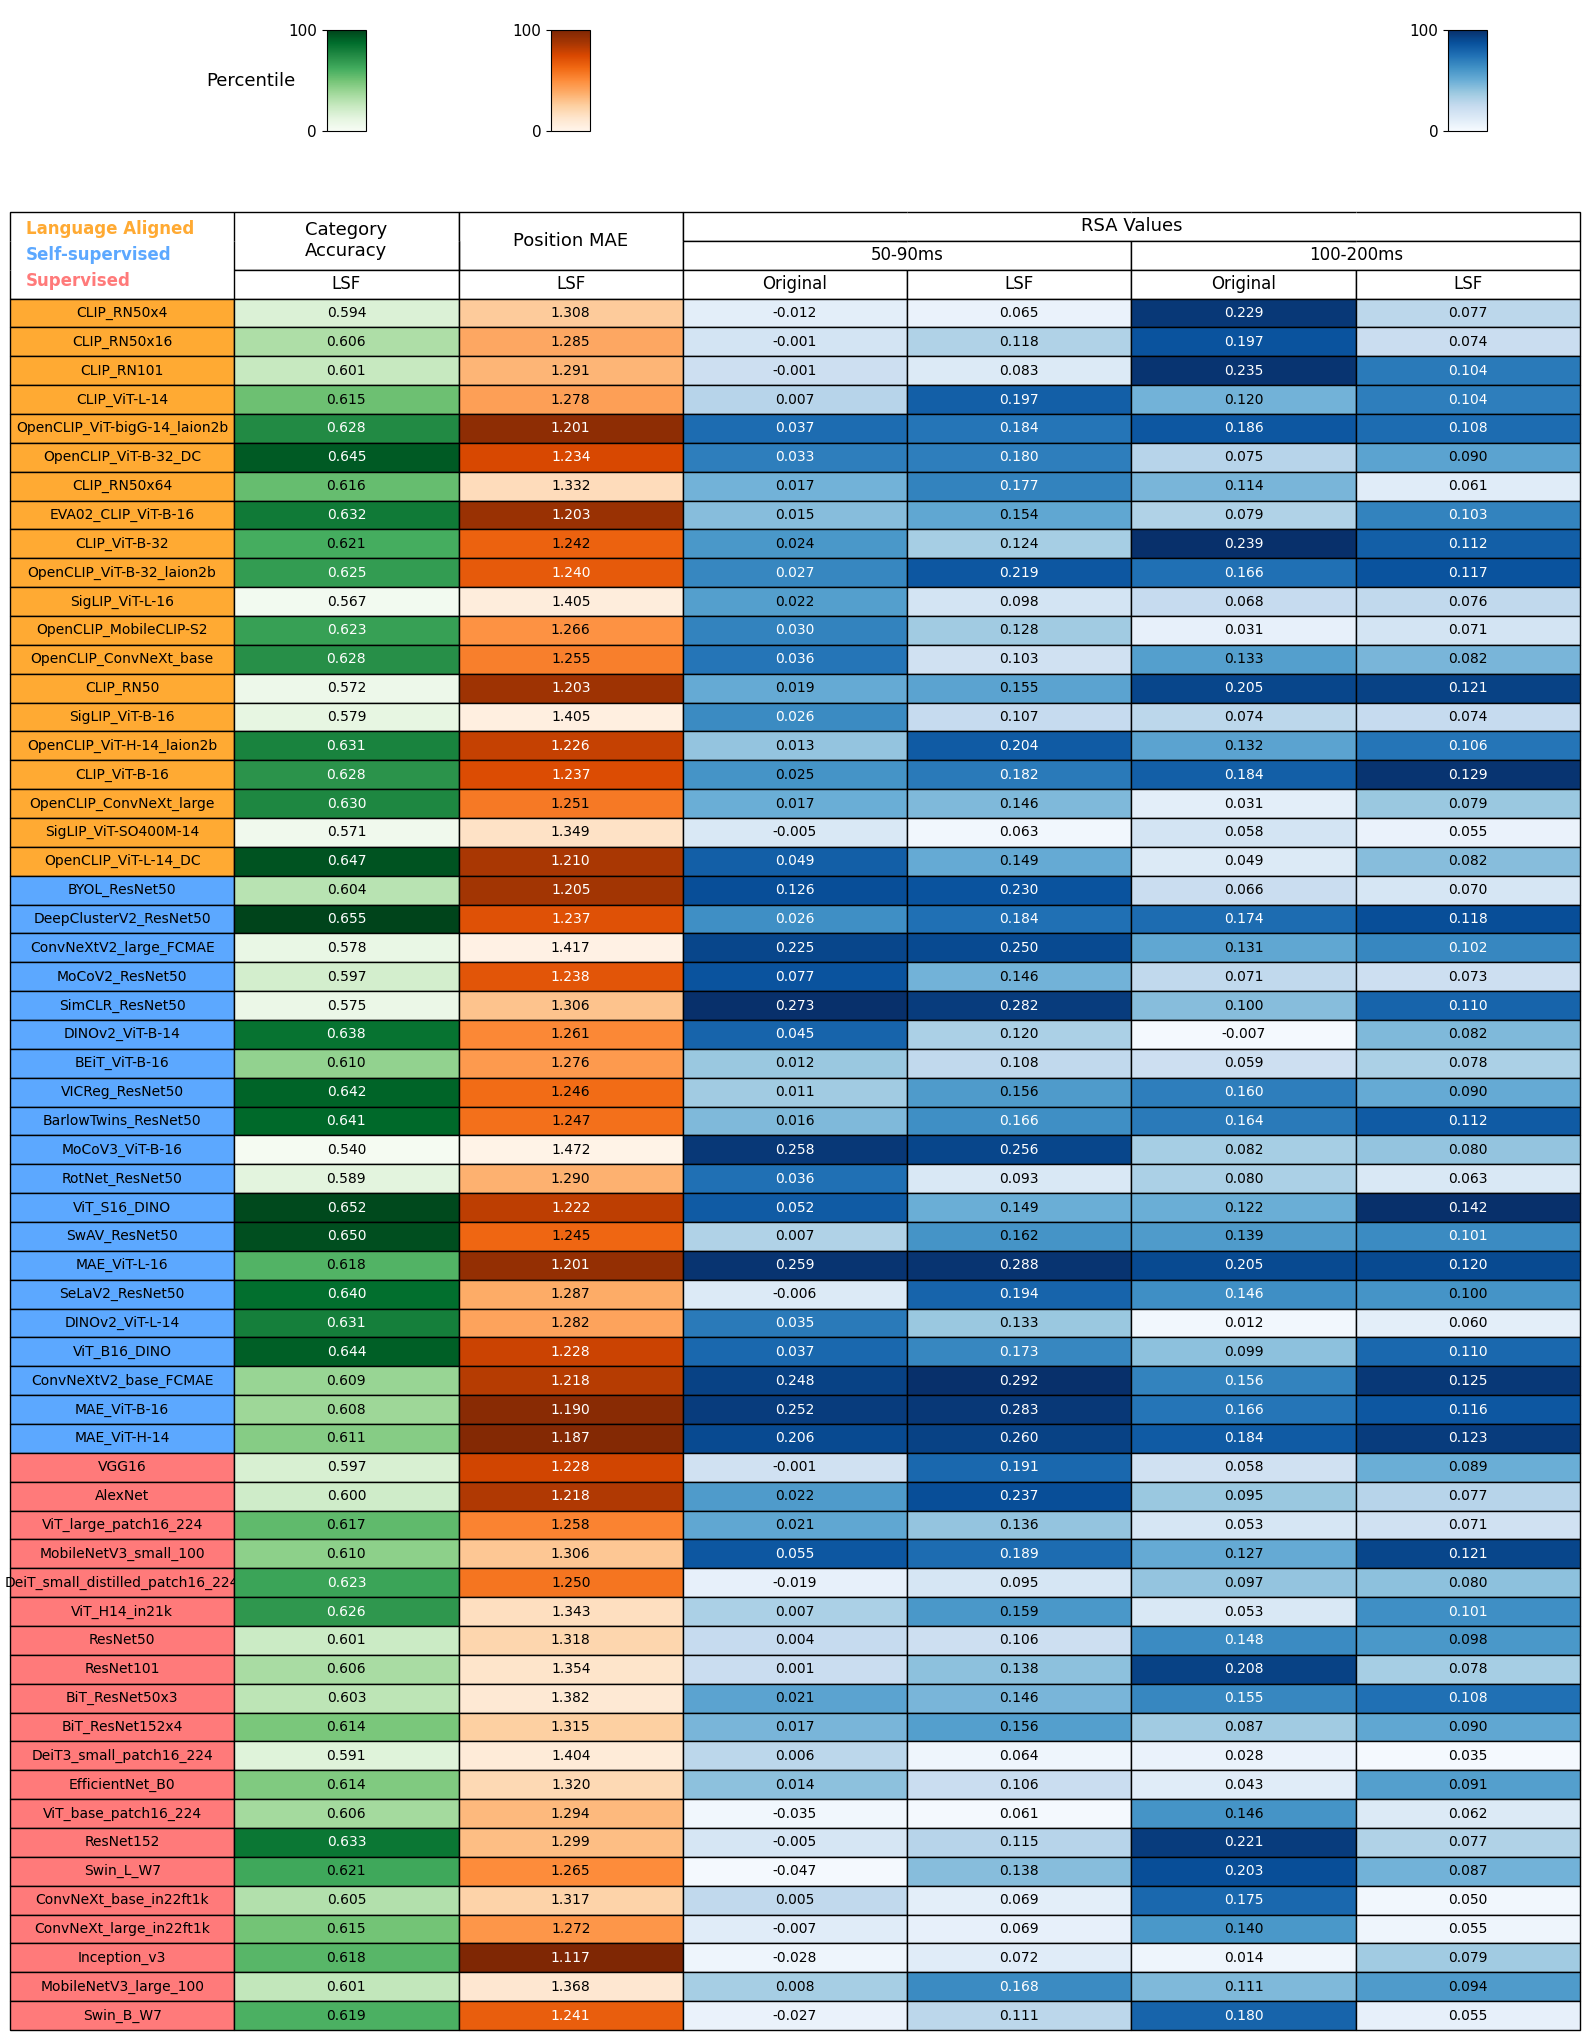

✅ Saved fully integrated metrics table to 'Figures/integrated_metrics_table.pdf'


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.stats import rankdata
import os
import re

# ──────────────────────────────────────────────────────────────────────
# 0. SETUP DIRECTORIES
# ──────────────────────────────────────────────────────────────────────
for folder in ['Figures', 'Statistics']:
    if not os.path.exists(folder):
        os.makedirs(folder)

# ──────────────────────────────────────────────────────────────────────
# 1. LOAD AND ALIGN DATA
# ──────────────────────────────────────────────────────────────────────
df_cat = pd.read_csv("downloads/category_decoding_accuracy.csv")
df_pos = pd.read_csv("downloads/position_decoding_mae.csv")
df_rsa = pd.read_csv("downloads/network_mean_rsas_all_conditions.csv")

def normalize_name(name):
    return re.sub(r'[^A-Za-z0-9]', '', str(name)).lower()

df_cat['norm_name'] = df_cat['network'].apply(normalize_name)
df_pos['norm_name'] = df_pos['network'].apply(normalize_name)
df_rsa['norm_name'] = df_rsa['Network'].apply(normalize_name)

df_merged = df_cat.merge(df_pos, on='norm_name', suffixes=('_cat', '_pos'))
df_merged = df_merged.merge(df_rsa, on='norm_name')

df_merged.sort_values(by='Training Type', inplace=True)
df_merged.reset_index(drop=True, inplace=True)

df_merged.to_csv("Statistics/merged_metrics_table.csv", index=False)
print("✅ Saved merged metrics data to 'Statistics/merged_metrics_table.csv'")

# ──────────────────────────────────────────────────────────────────────
# 2. CALCULATE PERCENTILES FOR HEATMAP COLORS
# ──────────────────────────────────────────────────────────────────────
cat_pct = rankdata(df_merged['category_accuracy']) / len(df_merged)
rsa1_pct = rankdata(df_merged['Mean RSA (50–90 ms, Original)']) / len(df_merged)
rsa2_pct = rankdata(df_merged['Mean RSA (50–90 ms, Low-pass)']) / len(df_merged)
rsa3_pct = rankdata(df_merged['Mean RSA (100–200 ms, Original)']) / len(df_merged)
rsa4_pct = rankdata(df_merged['Mean RSA (100–200 ms, Low-pass)']) / len(df_merged)

# Lower Position MAE is better -> rank inversely
pos_pct = rankdata(-df_merged['position_mae']) / len(df_merged)

# Colormaps
cmap_cat = plt.get_cmap('Greens')
cmap_pos = plt.get_cmap('Oranges')
cmap_rsa = plt.get_cmap('Blues')

# Updated category colors
training_colors = {
    'Supervised': '#FF7A7A',        # Saturated Red/Coral
    'Self-supervised': '#5CA8FF',   # Saturated Sky Blue
    'Language Aligned': '#FFAA33'   # Saturated Yellow-Orange
}

# ──────────────────────────────────────────────────────────────────────
# 3. FIGURE: MULTI-COLOR GRADIENT TABLE WITH COMPLEX HEADERS
# ──────────────────────────────────────────────────────────────────────
# Increase figure height slightly to make room for colorbars
fig1, ax1 = plt.subplots(figsize=(16, len(df_merged) * 0.3 + 2.5))
ax1.set_axis_off()

cell_text = []
cell_colors_multi = []

# --- Construct 3 Blank Header Rows (7 columns now) ---
for _ in range(3):
    cell_text.append([""] * 7)
    cell_colors_multi.append(["#FFFFFF"] * 7)

# --- Construct Data Rows ---
for i in range(len(df_merged)):
    t_type = df_merged['Training Type'].values[i]

    row_text = [
        df_merged['Network'].values[i],
        f"{df_merged['category_accuracy'].values[i]:.3f}",
        f"{df_merged['position_mae'].values[i]:.3f}",
        f"{df_merged['Mean RSA (50–90 ms, Original)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (50–90 ms, Low-pass)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (100–200 ms, Original)'].values[i]:.3f}",
        f"{df_merged['Mean RSA (100–200 ms, Low-pass)'].values[i]:.3f}"
    ]
    cell_text.append(row_text)

    row_colors = [
        training_colors.get(t_type, 'white'),
        colors.to_hex(cmap_cat(cat_pct[i])),
        colors.to_hex(cmap_pos(pos_pct[i])),
        colors.to_hex(cmap_rsa(rsa1_pct[i])),
        colors.to_hex(cmap_rsa(rsa2_pct[i])),
        colors.to_hex(cmap_rsa(rsa3_pct[i])),
        colors.to_hex(cmap_rsa(rsa4_pct[i]))
    ]
    cell_colors_multi.append(row_colors)

# Draw the table (without native column labels, we overlay our own)
table1 = ax1.table(cellText=cell_text, cellColours=cell_colors_multi,
                   cellLoc='center', bbox=[0, 0, 1, 0.90])
table1.auto_set_font_size(False)
table1.set_fontsize(10)

# Draw canvas first so we can extract exact coordinates for text overlay & borders
fig1.canvas.draw()

# --- Format Borders to Visually Merge Cells ---
# We use 'visible_edges' to hide internal borders of our 3 empty header rows

# Level 1 Headers (Row 0)
table1[0,0].visible_edges = 'LT'
table1[0,1].visible_edges = 'LRT'
table1[0,2].visible_edges = 'LRT'
table1[0,3].visible_edges = 'LTB'
table1[0,4].visible_edges = 'TB'
table1[0,5].visible_edges = 'TB'
table1[0,6].visible_edges = 'RTB'

# Level 2 Headers (Row 1)
table1[1,0].visible_edges = 'L'
table1[1,1].visible_edges = 'LRB' # Bottom border beneath Cat Acc
table1[1,2].visible_edges = 'LRB' # Bottom border beneath Pos MAE
table1[1,3].visible_edges = 'LTB'
table1[1,4].visible_edges = 'RTB'
table1[1,5].visible_edges = 'LTB'
table1[1,6].visible_edges = 'RTB'

# Level 3 Headers (Row 2)
table1[2,0].visible_edges = 'LB'
for c in range(1, 7):
    table1[2,c].visible_edges = 'LRTB'

# Adjust luminance for data rows text
for (row, col), cell in table1.get_celld().items():
    if row > 2 and col >= 1:
        bg_color = cell.get_facecolor()
        luminance = 0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2]
        if luminance < 0.5:
            cell.set_text_props(color='white')

# --- Inject Header Texts ---
def place_centered_text(r1, r2, c1, c2, text, fontsize=12):
    """Finds the bounding box of a logical cell span and centers text within it."""
    cell1 = table1[r1, c1]
    cell2 = table1[r2, c2]
    x_center = cell1.get_x() + (cell2.get_x() + cell2.get_width() - cell1.get_x()) / 2
    y_center = cell2.get_y() + (cell1.get_y() + cell1.get_height() - cell2.get_y()) / 2
    ax1.text(x_center, y_center, text, ha='center', va='center', fontsize=fontsize, weight='normal')

# Place data column headers (Shifted left by 1)
place_centered_text(0, 1, 1, 1, "Category\nAccuracy", 13)
place_centered_text(0, 1, 2, 2, "Position MAE", 13)
place_centered_text(0, 0, 3, 6, "RSA Values", 13)

place_centered_text(1, 1, 3, 4, "50-90ms", 12)
place_centered_text(1, 1, 5, 6, "100-200ms", 12)

for c in [1, 2]:
    place_centered_text(2, 2, c, c, "LSF", 12)

for c, txt in zip(range(3, 7), ["Original", "LSF", "Original", "LSF"]):
    place_centered_text(2, 2, c, c, txt, 12)

# --- Top Left Text Legend ---
c0 = table1[2, 0] # Bottom of the empty space
c1 = table1[0, 0] # Top of the empty space
x_leg = c0.get_x() + 0.01
y_bot = c0.get_y()
h_total = (c1.get_y() + c1.get_height()) - y_bot

ax1.text(x_leg, y_bot + h_total * 0.8, "Language Aligned", color=training_colors['Language Aligned'], va='center', ha='left', fontsize=12, fontweight='bold')
ax1.text(x_leg, y_bot + h_total * 0.5, "Self-supervised", color=training_colors['Self-supervised'], va='center', ha='left', fontsize=12, fontweight='bold')
ax1.text(x_leg, y_bot + h_total * 0.2, "Supervised", color=training_colors['Supervised'], va='center', ha='left', fontsize=12, fontweight='bold')

# --- Add Inline Colorbars (Percentiles) ---
y_cbar_bottom = 0.94
cbar_width = 0.025
cbar_height = 0.05

def add_inline_colorbar(col_idx, cmap, add_label=False):
    cell = table1[0, col_idx]
    x_center = cell.get_x() + cell.get_width() / 2

    # Create tiny axes right above the column
    ax_in = ax1.inset_axes([x_center - cbar_width/2, y_cbar_bottom, cbar_width, cbar_height])
    norm = colors.Normalize(vmin=0, vmax=100)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig1.colorbar(sm, cax=ax_in, orientation='vertical')
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.set_yticks([0, 100])
    cbar.ax.tick_params(labelsize=11)

    if add_label:
        ax1.text(x_center - cbar_width/2 - 0.02, y_cbar_bottom + cbar_height/2, "Percentile",
                 ha='right', va='center', fontsize=13)

# Place above new Cols 1, 2, and 6
add_inline_colorbar(1, cmap_cat, add_label=True)
add_inline_colorbar(2, cmap_pos)
add_inline_colorbar(6, cmap_rsa)

plt.tight_layout()
plt.savefig('Figures/integrated_metrics_table.pdf', format='pdf', bbox_inches='tight')
plt.show()
print("✅ Saved fully integrated metrics table to 'Figures/integrated_metrics_table.pdf'")

In [5]:
import shutil
from google.colab import files
import os

# Define the folders to be zipped
folders_to_zip = ['Figures', 'Statistics']
zip_filename = 'DNN_comparison_table.zip'

# Create a temporary directory to gather files if needed, or zip directly
# We will zip them into one file
with open('temp_file_list.txt', 'w') as f:
    pass # placeholder

# Zipping the folders
print(f"📦 Zipping {folders_to_zip}...")
os.system(f"zip -r {zip_filename} Figures Statistics")

# Trigger download
if os.path.exists(zip_filename):
    print(f"🚀 Downloading {zip_filename}...")
    files.download(zip_filename)
else:
    print("❌ Error: Zip file was not created.")

📦 Zipping ['Figures', 'Statistics']...
🚀 Downloading DNN_comparison_table.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>